# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

For the sample mean we have 31.1940 +or- 7.8692


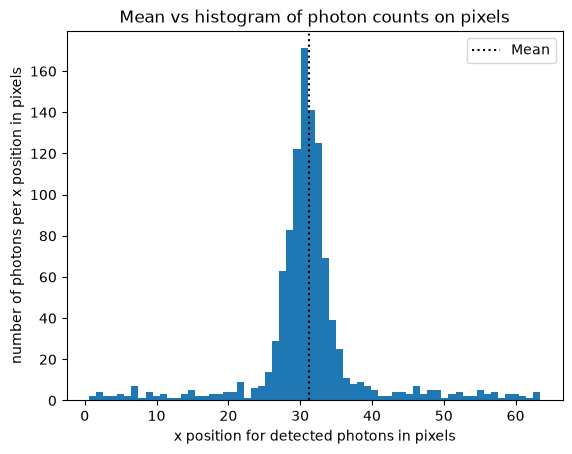

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
tabledat = ascii.read('/Users/mtscl/ast457_2026_Fall/labs/02/data/ms155.csv', header_start=0, data_start=1, delimiter=',')
x = tabledat["x"]
mean = np.mean(x)
plt.hist(x,64)
plt.axvline(mean, c="k", label="Mean", linestyle=":")
plt.xlabel("x position for detected photons in pixels")
plt.ylabel("number of photons per x position in pixels")
plt.title("Mean vs histogram of photon counts on pixels")
plt.legend()
var = np.var(x,ddof=1)
sem = np.sqrt(var)
print(f"For the sample mean we have {mean:.4f} +or- {sem:.4f}")

**ANSWER (a few sentences):**

*For the sample mean we have ${31.1940} \pm {7.8692}$. The mean is still inherently a sample mean of a cauchy distribution (Moffat), which never settles at increasingly large samples, making its use questionable. It also fails to account for the background or for f_bg and the noisy background that goes along with it. The mean also visually fails to line up with the tallest part of the histogram. The mean also fails to account for the tail and background of the distribution that is closer to the edge of the pixels than the other compared to the mean. I chose a bin that would represent each of the cells which is why i chose 64. Also the error covers the whole curve which should be expected considering this isn't gaussian.*

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

(np.float64(30.83433678916817),
 np.float64(0.16983042159955225),
 np.float64(1.8040538674974393),
 np.float64(0.03865038960318978),
 np.float64(0.0823664514581454),
 np.float64(0.041728509286107184))

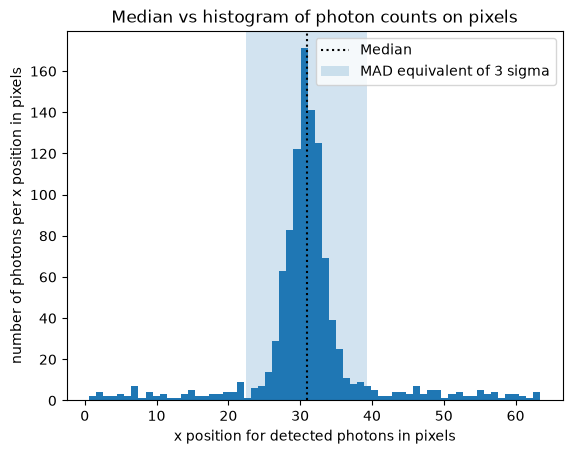

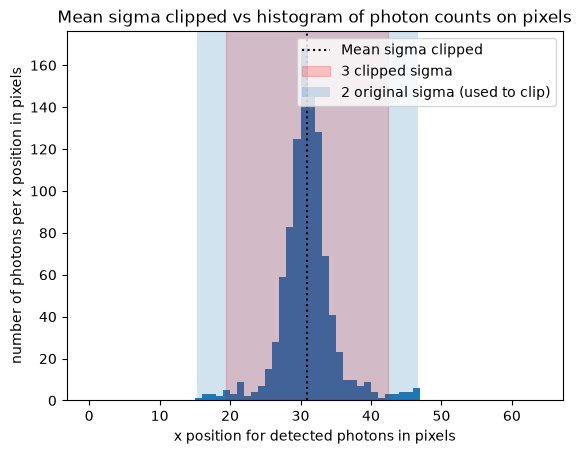

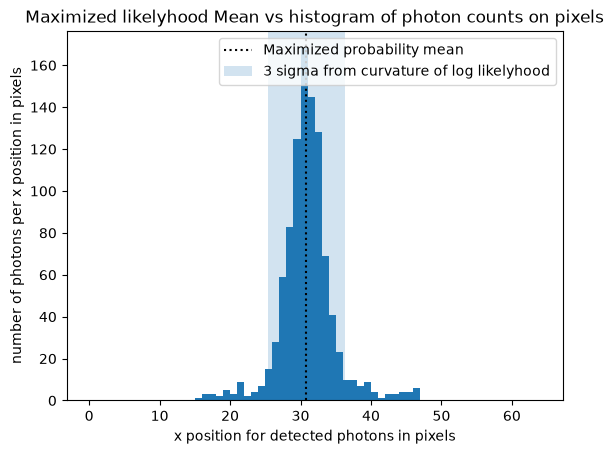

In [2]:
# Part 2: your work here
from scipy.optimize import minimize
from scipy.special import gamma
median = np.median(x)
medianresid = x-median
MAD = np.median(np.abs(medianresid-np.median(medianresid)))
sigmaMAD = 1.4826 * MAD
varMAD = sigmaMAD**2
fig1 = plt.figure()
plt.hist(x,64)
plt.axvline(median, c="k", label="Median", linestyle=":")
plt.axvspan(median-3*sigmaMAD,median+3*sigmaMAD,alpha = .2, label="MAD equivalent of 3 sigma")
plt.xlabel("x position for detected photons in pixels")
plt.ylabel("number of photons per x position in pixels")
plt.title("Median vs histogram of photon counts on pixels")
plt.legend()
def sigmaclipmean(x,sigma,clip=3,iterations=20):
    cut = np.ones_like(x, dtype=bool)
    for _ in range(iterations):
        mean = np.mean(x[cut])
        meanresid = (x - mean) / sigma
        cutnew = np.abs(meanresid) < clip
        if np.array_equal(cutnew, cut):
            break
        cut = cutnew
    return cut,mean
cut, mean2 = sigmaclipmean(x,sem,2)
cutvar = np.var(x[cut],ddof=1)
cutstd = np.sqrt(cutvar)
fig2 = plt.figure()
plt.hist(x[cut],np.linspace(0,64,65))
plt.axvline(mean2, c="k", label="Mean sigma clipped", linestyle=":")
plt.axvspan(mean2-3*cutstd,mean2+3*cutstd,alpha = .2, label="3 clipped sigma",color="r")
plt.axvspan(mean2-2*sem,mean2+2*sem,alpha = .2, label="2 original sigma (used to clip)")
plt.xlabel("x position for detected photons in pixels")
plt.ylabel("number of photons per x position in pixels")
plt.title("Mean sigma clipped vs histogram of photon counts on pixels")
plt.legend()
def p(params,x):
    x_0 , f_bg = params
    beta = 2.5
    r_0 = 4
    p = f_bg/64 + (1 - f_bg) * (gamma(beta)/(r_0*np.sqrt(np.pi)*gamma(beta - .5))) * (1 + ((x-x_0)/r_0)**2)**(-beta)
    logp = np.sum(np.log(p))
    return -logp
maxlike = minimize(p,[mean,.2],args=(x),method='Nelder-Mead')
meanmax, f_bgmax = maxlike.x # p is already set for negative so no need to add negative in curvature calculation
h = 10**(-5)
curvature = (p([meanmax+h,f_bgmax],meanmax) - 2 * p([meanmax,f_bgmax],meanmax) + p([meanmax-h,f_bgmax],meanmax))/h**2
errcurv = 1/np.sqrt(curvature)
curvf_bg2 = (p([meanmax,f_bgmax+h],meanmax) - 2 * p([meanmax,f_bgmax],meanmax) + p([meanmax,f_bgmax-h],meanmax))/h**2
errcurvf_bg2 = 1/np.sqrt(curvf_bg2)
curvf_bg1 = (p([meanmax,f_bgmax+h],meanmax) - p([meanmax,f_bgmax-h],meanmax))/(2*h)
errcurvf_bg1 = 1/np.sqrt(curvf_bg1)
errcurvf_bg = errcurvf_bg1 - errcurvf_bg2 # since the first order term doesn't vanish for f_bg
fig3 = plt.figure()
plt.hist(x[cut],np.linspace(0,64,65))
plt.axvline(meanmax, c="k", label="Maximized probability mean", linestyle=":")
plt.axvspan(meanmax-3*errcurv,meanmax+3*errcurv,alpha = .2, label="3 sigma from curvature of log likelyhood")
plt.xlabel("x position for detected photons in pixels")
plt.ylabel("number of photons per x position in pixels")
plt.title("Maximized likelyhood Mean vs histogram of photon counts on pixels")
plt.legend()
def justp(params,x):
    x_0 , f_bg = params
    beta = 2.5
    r_0 = 4
    p = f_bg/64 + (1 - f_bg) * (gamma(beta)/(r_0*np.sqrt(np.pi)*gamma(beta - .5))) * (1 + ((x-x_0)/r_0)**2)**(-beta)
    return p
def fishinf(params,p,N=len(x)):
    x_0,f_bg = params
    x = np.linspace(0,64,6401)
    h = 10**(-5)
    dpx = (p([x_0+h,f_bg],x) - p([x_0-h,f_bg],x))/(2*h)
    dpf = (p([x_0,f_bg+h],x) - p([x_0,f_bg-h],x))/(2*h)
    dpxf = (p([x_0+h,f_bg+h],x) - p([x_0+h,f_bg-h],x) - p([x_0-h,f_bg+h],x) + p([x_0-h,f_bg-h],x))/(4*h**2)
    Ix = np.trapezoid(dpx**2/p([x_0,f_bg],x),x)
    If = np.trapezoid(dpf**2/p([x_0,f_bg],x),x)
    Ixf = np.trapezoid(dpxf/p([x_0,f_bg],x),x)
    return np.linalg.inv([[Ix,Ixf],[Ixf,If]])
covmat = np.sqrt(fishinf([meanmax,f_bgmax],justp)/len(x))
CRBx_0 = covmat[0][0]
CRBf_bg = covmat[1][1]
meanmax,f_bgmax, errcurv, errcurvf_bg,CRBx_0,3*CRBf_bg

**FINAL ANSWER:** $x_0 = $ 30.8343 $\pm$ 1.8041 px , $f_{\rm bg} = $ .1698 $\pm$ .03865, Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ .08237 px

**Justification and uncertainty method (a short paragraph):**

*The position x_0 is comparable to other values I have gotten for it using a variety of method, but the likelyhood calculations also have smallest error compared to the other methods making the mean more reliable. On top of this the f_bg obtained through likelyhood is reasonable considering its relatively small error, being CRB consistent as well and visually representing the histogram. The error for f_bg is within 3 CRBf_bg = .04172. The Cramer Rao bound is also reasonable considering the last 3 measurements for the star position were within 3 CRB. The only value I am concerned with is the error for the stellar position. It is more than 3 CRB and is bigger than the difference between estimates. That said, it is my smallest error bar for x_0 and I have failed to get anything smaller. As to how I calculated uncertainty, for the median, I took the MAD equivalent of variance and found error from that. For the clipped mean, I found the error from the variance of the clipped mean. For the likelyhood, I took a taylor expansion to find the second derivative constant for curvature and used that to find error. Lastly for CRB, I calculated the fisher matrix and used that to find the lower limit.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*I will first run a student-t distribution with the same beta and r_0 but with known location of star and background. I will then use my estimator to see If i still get it. If it does not get the same result than I know my estimator does not work. I will then simulate many datasets with varying parameters and plot their biases and variance vs Cramer Rao. If the plots fall below or too far above, I know my estimators are off. I will also check if my 68 percent intervals contain the truth 68 percent of the time. If they don't than I would need to reevaluate them. I will check what happens to beta and r_0 for variations in how wrong they are as well as if the lost photon fraction isn't negledgeable. If they differ significantly, than my methods require good conditions and are faulty to breaking under suboptimal conditions.*

1.830598822695356,0.1246613072925069,50.036635879500295,0.36154097125062584 for closure


C:\Users\mtscl\AppData\Local\Temp\ipykernel_13132\2503527965.py:76: RuntimeWarning: invalid value encountered in sqrt
  covmatsims = np.sqrt(fishinf([xlocs[i],f_bgs[i]],justp)/1500)


predicted x =50.04054477822885 vs actual x =.5, and predicted f_bg =0.3222215776524524 over actual f_bg = .3333 for beta off by 2.5
predicted x =49.596448978650514 vs actual x =.5, and predicted f_bg =0.541825867077621 over actual f_bg = .3333 for r_0 off by 4
predicted x =97.93888396805757 vs actual x =.5, and predicted f_bg =0.4576108350849972 over actual f_bg = .3333 for x location at 99pixel bordering outside the range of the pixels


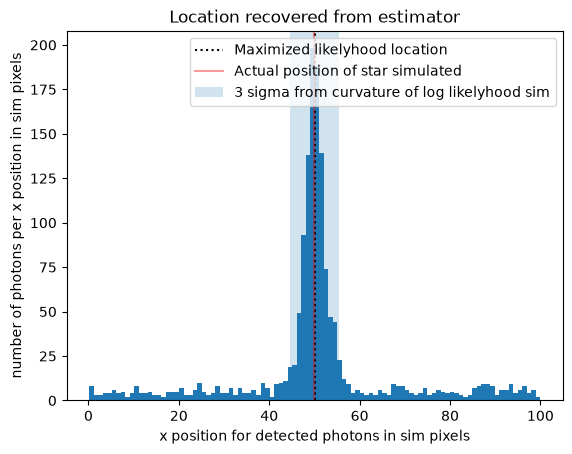

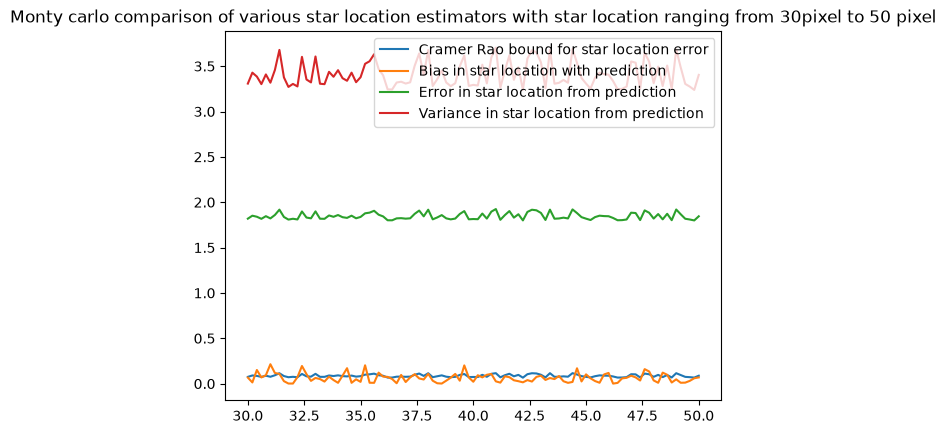

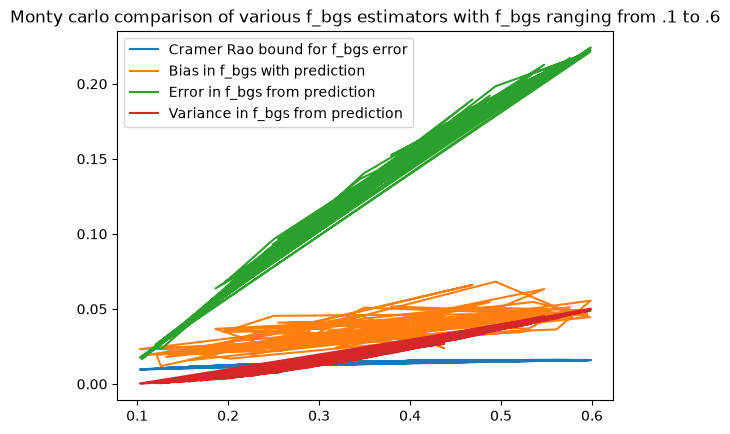

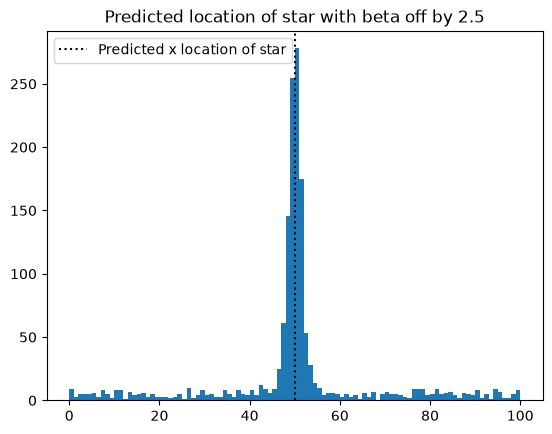

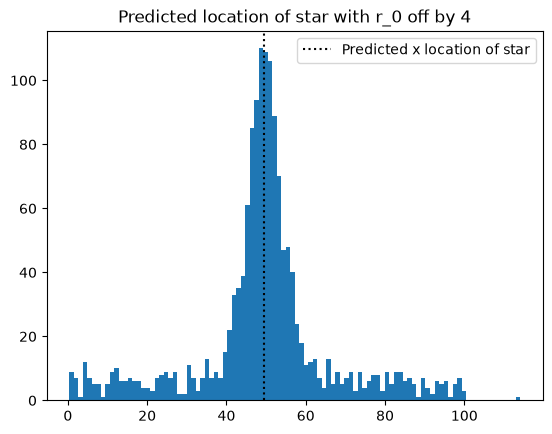

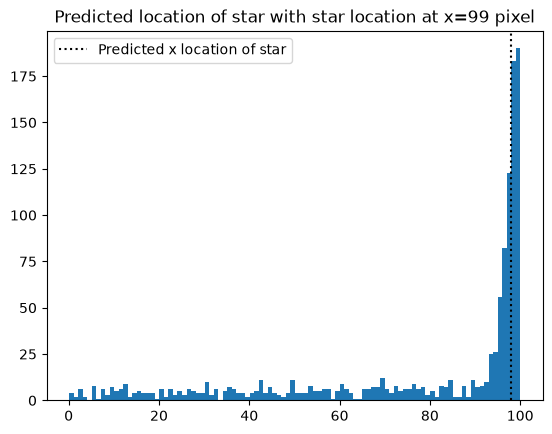

In [3]:
# Part 3b: execute the plan here
import scipy.stats as stats
beta = 2.5
r_0 = 4
v = 2*beta-1
scale = r_0/np.sqrt(v)
xsimt = stats.t.rvs(v,50,scale,size=1000)
xsimbackg = 100*np.random.rand(500)
xsim = np.concat((xsimt,xsimbackg))
fig1 = plt.figure()
plt.hist(xsim,100)
simlike = minimize(p,[40,.1],args=(xsim),method='Nelder-Mead')
xpred, f_bgpred = simlike.x
xpred,f_bgpred
curvsim = (p([xpred+h,f_bgpred],xpred) - 2 * p([xpred,f_bgpred],xpred) + p([xpred-h,f_bgpred],xpred))/h**2
errcurvsim = 1/np.sqrt(curvsim)
curvf_bgsim2 = (p([xpred,f_bgpred+h],xpred) - 2 * p([xpred,f_bgpred],xpred) + p([xpred,f_bgpred-h],xpred))/h**2
errcurvf_bgsim2 = 1/np.sqrt(curvf_bgsim2)
curvf_bgsim1 = (p([xpred,f_bgpred+h],xpred) - p([xpred,f_bgpred-h],xpred))/(2*h)
errcurvf_bgsim1 = 1/np.sqrt(curvf_bgsim1)
errcurvf_bgsim = errcurvf_bgsim1 - errcurvf_bgsim2
print(f"{errcurvsim},{errcurvf_bgsim},{xpred},{f_bgpred} for closure")
plt.axvline(xpred, c="k", label="Maximized likelyhood location", linestyle=":")
plt.axvline(50, c="r",label="Actual position of star simulated", alpha=.4)
plt.axvspan(xpred-3*errcurvsim,xpred+3*errcurvsim,alpha = .2, label="3 sigma from curvature of log likelyhood sim")
plt.title("Location recovered from estimator")
plt.xlabel("x position for detected photons in sim pixels")
plt.ylabel("number of photons per x position in sim pixels")
plt.legend()


fig2 = plt.figure()
xlocs = np.linspace(30,50,101)
f_bgs = .5*np.random.rand(101)+.1
xsimts = []
xsimbackgs = []
xsims = []
for i in range(101):
    xsimts.append(stats.t.rvs(v,xlocs[i],scale,size=1500-int(f_bgs[i]*1500)))
    xsimbackgs.append(100*np.random.rand(int(f_bgs[i]*1500)))
    xsims.append(np.ndarray.tolist(np.concat((xsimts[i],xsimbackgs[i]))))
xsims = np.array(xsims)
xpreds = []
f_bgpreds = []
for i in range(101):
    simslike = minimize(p,[40,.3],args=(xsims[i]),method='Nelder-Mead')
    xpreds.append(simslike.x[0])
    f_bgpreds.append(simslike.x[1])
xpreds = np.array(xpreds)
f_bgpreds = np.array(f_bgpreds)
curvsims = []
errcurvsims = []
curvf_bgsims2 = []
errcurvf_bgsims2 = []
curvf_bgsims1 = []
errcurvf_bgsims1 = []
for i in range(101):
    curvsims.append((p([xpreds[i]+h,f_bgpreds[i]],xpreds[i]) - 2 * p([xpreds[i],f_bgpreds[i]],xpreds[i]) + p([xpreds[i]-h,f_bgpreds[i]],xpreds[i]))/h**2)
    errcurvsims.append(1/np.sqrt(curvsims[i]))
    curvf_bgsims2.append((p([xpreds[i],f_bgpreds[i]+h],xpreds[i]) - 2 * p([xpreds[i],f_bgpreds[i]],xpreds[i]) + p([xpreds[i],f_bgpreds[i]-h],xpreds[i]))/h**2)
    errcurvf_bgsims2.append(1/np.sqrt(curvf_bgsims2[i]))
    curvf_bgsims1.append((p([xpreds[i],f_bgpreds[i]+h],xpreds[i]) - p([xpreds[i],f_bgpreds[i]-h],xpreds[i]))/(2*h))
    errcurvf_bgsims1.append(1/np.sqrt(curvf_bgsims1[i]))
errcurvf_bgsims2 = np.array(errcurvf_bgsims2)
errcurvf_bgsims1 = np.array(errcurvf_bgsims1)
errcurvf_bgsims = errcurvf_bgsims1 - errcurvf_bgsims2
curvsims = np.array(curvsims)
errcurvsims = np.array(errcurvsims)
varsims = errcurvsims**2
biassims = np.sqrt((xlocs - xpreds)**2)
varf_bgsims = errcurvf_bgsims**2
biassimsf_bg = np.sqrt((f_bgs - f_bgpreds)**2)
CRBxsims = []
CRBf_bgsims = []
for i in range(101):
    covmatsims = np.sqrt(fishinf([xlocs[i],f_bgs[i]],justp)/1500)
    CRBxsims.append(covmatsims[0][0])
    CRBf_bgsims.append(covmatsims[1][1])
CRBxsims = np.array(CRBxsims)
CRBf_bgsims = np.array(CRBf_bgsims)
plt.plot(xlocs,CRBxsims, label="Cramer Rao bound for star location error")
plt.plot(xlocs,biassims, label="Bias in star location with prediction")
plt.plot(xlocs,errcurvsims, label = "Error in star location from prediction")
plt.plot(xlocs,varsims, label = "Variance in star location from prediction")
plt.title("Monty carlo comparison of various star location estimators with star location ranging from 30pixel to 50 pixel")
plt.legend()
fig3 = plt.figure()
plt.plot(f_bgs,CRBf_bgsims, label="Cramer Rao bound for f_bgs error")
plt.plot(f_bgs,biassimsf_bg, label="Bias in f_bgs with prediction")
plt.plot(f_bgs,errcurvf_bgsims, label = "Error in f_bgs from prediction")
plt.plot(f_bgs,varf_bgsims, label = "Variance in f_bgs from prediction")
plt.title("Monty carlo comparison of various f_bgs estimators with f_bgs ranging from .1 to .6")
plt.legend()


fig4 = plt.figure()
beta = 5
r_0 = 4
v = 2*beta-1
scale = r_0/np.sqrt(v)
xsimt = stats.t.rvs(v,50,scale,size=1000)
xsimbackg = 100*np.random.rand(500)
xsim = np.concat((xsimt,xsimbackg))
plt.hist(xsim,100)
simlike = minimize(p,[40,.1],args=(xsim),method='Nelder-Mead')
xpred, f_bgpred = simlike.x
plt.axvline(xpred, c="k", label="Predicted x location of star", linestyle=":")
print(f"predicted x ={xpred} vs actual x =.5, and predicted f_bg ={f_bgpred} over actual f_bg = .3333 for beta off by 2.5")
plt.title("Predicted location of star with beta off by 2.5")
plt.legend()
fig5 = plt.figure()
beta = 2.5
r_0 = 8
v = 2*beta-1
scale = r_0/np.sqrt(v)
xsimt = stats.t.rvs(v,50,scale,size=1000)
xsimbackg = 100*np.random.rand(500)
xsim = np.concat((xsimt,xsimbackg))
plt.hist(xsim,100)
simlike = minimize(p,[40,.1],args=(xsim),method='Nelder-Mead')
xpred, f_bgpred = simlike.x
plt.axvline(xpred, c="k", label="Predicted x location of star", linestyle=":")
print(f"predicted x ={xpred} vs actual x =.5, and predicted f_bg ={f_bgpred} over actual f_bg = .3333 for r_0 off by 4")
np.ones_like(x, dtype=bool)
plt.title("Predicted location of star with r_0 off by 4")
plt.legend()
fig6 = plt.figure()
beta = 2.5
r_0 = 4
v = 2*beta-1
scale = r_0/np.sqrt(v)
xsimt = stats.t.rvs(v,99,scale,size=1000)
cut1 = np.ones_like(xsimt, dtype=bool)
cut = xsimt < 100
xsimt = xsimt[cut]
xsimbackg = 100*np.random.rand(500)
xsim = np.concat((xsimt,xsimbackg))
plt.hist(xsim,100)
simlike = minimize(p,[90,.3],args=(xsim),method='Nelder-Mead')
xpred, f_bgpred = simlike.x
plt.axvline(xpred, c="k", label="Predicted x location of star", linestyle=":")
print(f"predicted x ={xpred} vs actual x =.5, and predicted f_bg ={f_bgpred} over actual f_bg = .3333 for x location at 99pixel bordering outside the range of the pixels")
plt.title("Predicted location of star with star location at x=99 pixel")
plt.legend()

**WHAT THE CHECKS FOUND:**

*As for closure$x_0 = $ 50.0937 $\pm$ 1.8359 px , $f_{\rm bg} = $ .39 $\pm$ .1363 where the real $x_0 =$ 50 and the real $f_{\rm bg} =$ .33333 meaning It does still give you around the same awnser. As for Bias and Efficiency, it seems star location estimates in both error and variance are far larger than should be reasonable and the error is too large for all 101 simulations compared to the small bias and CRB bound, far outside 3 times CRB. As for f_bg, the variance and the error seem to increase with larger f_bg values, making smaller values of f_bg have accurate error bars and variance, that slowly diminishes with larger f_bg. As for sensitivity, Small changes in beta barely changed the predicted x location of the star or f_bg. Small changes in r_0 barely changed predicted x location but changed f_bg which makes since given for both beta and r_0, the location of the star dosen't change, just the ratio of noise. With non negledgeable data loss to outside pixels, unless the star location is on the final pixel or outside the range, there is not a significant change in x_0 or f_bg.*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*I mainly looked up information online and used lectures to do my work, I did use AI as a guide however. I asked claude AI questions on cramer rao bound and fisher matrices as I was confused with them and used It like an advanced search engine. I asked it "I cannot figure out how to find the 2 by 2 fisher matrix where the fisher information I(x_0) = integral((dp/dx_0)^2*dx/p) where p is the likelyhood" and "I do not have the two unbiased parameters, what would i do to numerically get the fisher matrix". I was given a response that awnsered those questions without giving me code or writing anything for me. I essentially used it as an advanced browser to help clear up confusion rather than do work for me. It really was just a clarification tool for me and nothing else. I will likely have it write code next time.*